In [ ]:
import numpy as np
from typing import List
import matplotlib.pyplot as plt

def improved_bm(seed: int, n_samples: int) -> List[float]:
  np.random.seed(seed)
  res = np.zeros((n_samples, 2), dtype=float)
  for i in range(n_samples):
    u = -1 + 2 * np.random.uniform(size=(2, ))
    S = np.sum(u ** 2)
    while S >= 1.0:
      u = np.random.uniform(size=(2, ))
      S = np.sum(u**2)
    res[i] = u*np.sqrt(-2*np.log(S)/S)
  return res

my_samples = improved_bm(0, 1000)

(array([ 1.,  0.,  0.,  0.,  1.,  1.,  0.,  0.,  3.,  0.,  0.,  0.,  1.,
         2.,  0.,  1.,  3.,  0.,  3.,  1.,  4.,  6.,  4.,  8.,  3.,  4.,
         5., 10.,  9.,  5.,  7.,  8., 12., 14.,  9., 11., 12., 14., 10.,
        14., 15., 15., 13., 15., 19., 15., 23., 15., 14., 21., 18., 20.,
        29., 27., 29., 29., 25., 29., 37., 23., 21., 26., 33., 17., 14.,
        20., 23., 15., 16., 19., 20., 13., 17.,  9.,  8., 14., 12.,  8.,
         8.,  7.,  9.,  7., 11.,  4.,  6.,  5.,  4.,  5.,  2.,  4.,  2.,
         0.,  2.,  0.,  0.,  0.,  0.,  0.,  1.,  1.]),
 array([-3.04614305, -2.98725328, -2.9283635 , -2.86947373, -2.81058395,
        -2.75169417, -2.6928044 , -2.63391462, -2.57502484, -2.51613507,
        -2.45724529, -2.39835552, -2.33946574, -2.28057596, -2.22168619,
        -2.16279641, -2.10390663, -2.04501686, -1.98612708, -1.92723731,
        -1.86834753, -1.80945775, -1.75056798, -1.6916782 , -1.63278842,
        -1.57389865, -1.51500887, -1.4561191 , -1.39722932, -1.338339

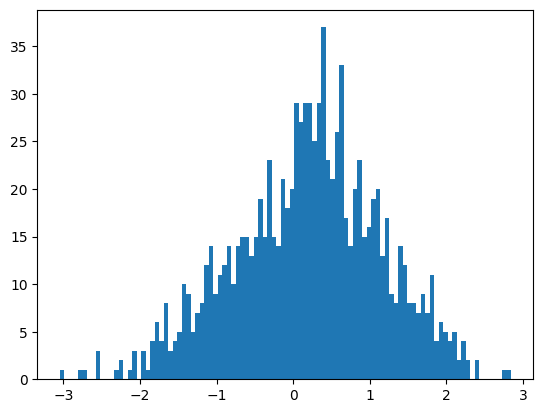

In [ ]:
plt.hist(my_samples[:, 0], bins=100)

In [ ]:
import jax
import jax.numpy as jnp

n_shape = 100
def my_func(key):
  X = jax.random.uniform(key, shape=(n_shape, n_shape))
  return X@X.T

OP_key = jax.random.PRNGKey(0)
keys = jax.random.split(OP_key, 10000)
jax.vmap(lambda k: my_func(k))(keys)



Array([[[38.570107, 27.459774, 28.289022, ..., 28.867405, 24.156277,
         27.921469],
        [27.459774, 33.808697, 24.835337, ..., 29.232796, 21.851131,
         23.97527 ],
        [28.289022, 24.835337, 32.821552, ..., 28.21415 , 22.201841,
         26.55209 ],
        ...,
        [28.867407, 29.2328  , 28.214151, ..., 39.080444, 25.145477,
         29.820503],
        [24.156282, 21.851128, 22.201838, ..., 25.145477, 29.136074,
         25.011068],
        [27.92147 , 23.97528 , 26.55209 , ..., 29.820503, 25.011068,
         38.08948 ]],

       [[28.678234, 21.176884, 20.815504, ..., 22.692253, 20.628014,
         21.84123 ],
        [21.176884, 31.579737, 23.654179, ..., 24.63316 , 22.946165,
         26.033796],
        [20.815504, 23.654179, 30.764833, ..., 21.825151, 21.192284,
         23.572678],
        ...,
        [22.692255, 24.633162, 21.825146, ..., 33.413013, 22.6473  ,
         26.638504],
        [20.628016, 22.94616 , 21.192287, ..., 22.6473  , 29.942299,
   

In [ ]:
"""
Improved box muller
"""

@jax.vmap
def one_sample(key):

  def cond(inps):
    _, __, s = inps
    return s >= 1.0

  def body(inps):
    key, u, s = inps
    key, subkey = jax.random.split(key, 2)
    u = 1-2*jax.random.uniform(subkey, shape=(2, ))
    s = jnp.sum(u**2)
    return key, u, s

  init = (key, jnp.zeros((2, )), jnp.inf)
  _, u, s = jax.lax.while_loop(cond, body, init)
  return jnp.sqrt(-2*jnp.log(s)/s) * u

OP_key = jax.random.PRNGKey(0)
n_samples = 10000000
my_keys = jax.random.split(OP_key, n_samples)
my_samples = one_sample(my_keys)

In [ ]:
my_samples

Array([[ 0.52902716,  0.20857418],
       [ 0.5134733 ,  0.17291963],
       [-0.88152546,  0.5559845 ],
       ...,
       [-0.7451495 ,  0.6513841 ],
       [ 1.0109875 , -0.9703311 ],
       [-0.15773517,  0.03033119]], dtype=float32)